# Cross-Validation Comparison

5-fold CV with per-user split within each fold — guarantees every user appears in both train and test across all folds.

**Models compared:**

| Model | Type |
|---|---|
| User+Item Bias | Non-ML baseline, no latent factors |
| CF (SGD) | Matrix Factorization via gradient descent |
| CF (SVD) | Matrix Factorization via closed-form decomposition |
| Content-Based | Item-item cosine similarity on genre + year |

**Metrics:** RMSE, MAE, Precision@10, Recall@10

**Why CV here?** Single train/test split results depend on which ratings happened to land in the test set. CV averages across 5 different splits, giving statistically reliable estimates and confidence intervals on the improvement of each model over the baseline.


## 1. Imports & Load Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import json

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3, ACCENT4 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9", "#F9E07D"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)

# load full filtered ratings (train + test combined — CV will re-split)
train = pd.read_csv("../data/processed/train.csv")
test  = pd.read_csv("../data/processed/test.csv")
ratings = pd.concat([train, test]).reset_index(drop=True)
movies  = pd.read_csv("../data/processed/movies_clean.csv")

N_USERS  = ratings.user_idx.nunique()
N_MOVIES = ratings.movie_idx.nunique()
RATING_MIN, RATING_MAX = 0.5, 5.0
K = 10

print(f"Total ratings : {len(ratings):,}")
print(f"Users         : {N_USERS}")
print(f"Movies        : {N_MOVIES}")


Total ratings : 81,116
Users         : 610
Movies        : 2269


## 2. Per-User K-Fold Split

For each fold:
- Split each user's ratings into train (80%) and test (20%) independently
- This guarantees every user appears in both splits in every fold
- Different from a global random split which could leave some users cold-start


In [3]:
def per_user_kfold(ratings, n_folds=5, seed=42):
    """
    Generate n_folds (train, test) splits using per-user holdout.
    Each fold holds out a different 1/n_folds chunk of each user's ratings.
    Returns list of (train_df, test_df) tuples.
    """
    rng = np.random.default_rng(seed)
    folds = []

    # assign each rating to a fold, per user
    fold_assignments = np.zeros(len(ratings), dtype=int)

    for _, group in ratings.groupby("user_idx"):
        idx  = group.index.to_numpy().copy()
        rng.shuffle(idx)
        # distribute ratings across folds as evenly as possible
        for k, i in enumerate(idx):
            fold_assignments[i] = k % n_folds

    for fold in range(n_folds):
        test_mask  = fold_assignments == fold
        train_mask = ~test_mask
        fold_train = ratings[train_mask].reset_index(drop=True)
        fold_test  = ratings[test_mask].reset_index(drop=True)
        folds.append((fold_train, fold_test))

    return folds

folds = per_user_kfold(ratings, n_folds=5)

print("Fold sizes:")
for i, (tr, te) in enumerate(folds):
    print(f"  Fold {i+1}:  train={len(tr):,}  test={len(te):,}  "
          f"train_users={tr.user_idx.nunique()}  test_users={te.user_idx.nunique()}")

# sanity check: all test users appear in train
for i, (tr, te) in enumerate(folds):
    assert set(te.user_idx) <= set(tr.user_idx), f"Fold {i+1} has cold-start users!"
print("\n✓ All test users appear in train across all folds")


Fold sizes:
  Fold 1:  train=64,660  test=16,456  train_users=610  test_users=610
  Fold 2:  train=64,784  test=16,332  train_users=610  test_users=610
  Fold 3:  train=64,889  test=16,227  train_users=610  test_users=610
  Fold 4:  train=65,001  test=16,115  train_users=610  test_users=610
  Fold 5:  train=65,130  test=15,986  train_users=610  test_users=610

✓ All test users appear in train across all folds


In [18]:
# ── Random Baseline (computed per fold) ───────────────────────────────
def compute_random_baseline(folds, k=10, threshold=4.0, seed=42):
    """
    For each fold:
      RMSE/MAE : predict Uniform(0.5, 5.0) for every test pair
      P@K/R@K  : sample K random unseen movies per user, compute hits
                 — same procedure as all other models
    """
    rng = np.random.default_rng(seed)
    results = {"rmse": [], "mae": [], "precision": [], "recall": []}

    for fold_train, fold_test in folds:
        actual = fold_test["rating"].values

        # RMSE / MAE
        random_preds = rng.uniform(RATING_MIN, RATING_MAX, size=len(actual))
        results["rmse"].append(rmse(actual, random_preds))
        results["mae"].append(mae(actual, random_preds))

        # P@K / R@K — sample K random unseen movies per user
        train_seen = fold_train.groupby("user_idx")["movie_idx"].apply(set).to_dict()
        test_relevant = (
            fold_test[fold_test["rating"] >= threshold]
            .groupby("user_idx")["movie_idx"]
            .apply(set)
            .to_dict()
        )

        precisions, recalls = [], []
        for user_idx, relevant in test_relevant.items():
            seen      = train_seen.get(user_idx, set())
            unseen    = np.array(list(set(range(N_MOVIES)) - seen))

            # sample exactly K random unseen movies — same as recommend() returning K items
            k_sample  = min(k, len(unseen))
            recs      = set(rng.choice(unseen, size=k_sample, replace=False))

            hits = len(recs & relevant)
            precisions.append(hits / k)
            recalls.append(hits / len(relevant) if relevant else 0.0)

        results["precision"].append(np.mean(precisions))
        results["recall"].append(np.mean(recalls))

    return results

random_results = compute_random_baseline(folds, k=K)

print("Random Baseline (per fold):")
print(f"  RMSE      : {np.mean(random_results['rmse']):.4f} ± {np.std(random_results['rmse']):.4f}")
print(f"  MAE       : {np.mean(random_results['mae']):.4f} ± {np.std(random_results['mae']):.4f}")
print(f"  P@{K}      : {np.mean(random_results['precision']):.4f} ± {np.std(random_results['precision']):.4f}")
print(f"  R@{K}      : {np.mean(random_results['recall']):.4f} ± {np.std(random_results['recall']):.4f}")

Random Baseline (per fold):
  RMSE      : 1.8452 ± 0.0032
  MAE       : 1.5067 ± 0.0029
  P@10      : 0.0068 ± 0.0011
  R@10      : 0.0052 ± 0.0012


## 3. Evaluation Metrics

In [4]:
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

def mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

def precision_recall_at_k(recommend_fn, test_df, train_df, k=10, threshold=4.0):
    train_seen = train_df.groupby("user_idx")["movie_idx"].apply(set).to_dict()
    test_relevant = (
        test_df[test_df["rating"] >= threshold]
        .groupby("user_idx")["movie_idx"]
        .apply(set)
        .to_dict()
    )
    precisions, recalls = [], []
    for user_idx, relevant in test_relevant.items():
        seen    = train_seen.get(user_idx, set())
        recs    = recommend_fn(user_idx, k, seen)
        rec_set = {m for m, _ in recs}
        hits    = len(rec_set & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant) if relevant else 0.0)
    p = np.mean(precisions)
    r = np.mean(recalls)
    return p, r


## 4. Model Definitions

### 4a. User+Item Bias

In [5]:
class UserItemBias:
    def __init__(self, beta=10):
        self.beta = beta
        self.mu = 0.0
        self.bu = {}
        self.bi = {}

    def fit(self, train_df):
        self.mu = train_df["rating"].mean()

        user_stats = train_df.groupby("user_idx")["rating"].agg(["sum","count"])
        self.bu = ((user_stats["sum"] - user_stats["count"] * self.mu)
                   / (user_stats["count"] + self.beta)).to_dict()

        item_stats = train_df.groupby("movie_idx")["rating"].agg(["sum","count"])
        self.bi = ((item_stats["sum"] - item_stats["count"] * self.mu)
                   / (item_stats["count"] + self.beta)).to_dict()

    def predict_batch(self, user_idxs, movie_idxs):
        bu = np.array([self.bu.get(u, 0.0) for u in user_idxs])
        bi = np.array([self.bi.get(i, 0.0) for i in movie_idxs])
        return self.mu + bu + bi

    def recommend(self, user_idx, n=10, seen_items=None):
        all_movies = np.arange(N_MOVIES)
        if seen_items is not None:
            mask = ~np.isin(all_movies, list(seen_items))
            candidates = all_movies[mask]
        else:
            candidates = all_movies
        scores = np.clip(
            self.mu + self.bu.get(user_idx, 0.0)
            + np.array([self.bi.get(i, 0.0) for i in candidates]),
            RATING_MIN, RATING_MAX
        )
        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return list(zip(candidates[top_idx], scores[top_idx]))


### 4b. CF (SGD)

In [6]:
class SGDMatrixFactorization:
    def __init__(self, n_users, n_movies, n_factors=35, lr=0.02, reg=0.12, seed=42):
        self.n_factors = n_factors
        self.lr, self.reg = lr, reg
        rng   = np.random.default_rng(seed)
        scale = 1.0 / np.sqrt(n_factors)
        self.P  = rng.normal(0, scale, (n_users,  n_factors))
        self.Q  = rng.normal(0, scale, (n_movies, n_factors))
        self.bu = np.zeros(n_users)
        self.bi = np.zeros(n_movies)
        self.mu = 0.0

    def predict_one(self, u, i):
        return self.mu + self.bu[u] + self.bi[i] + self.P[u] @ self.Q[i]

    def predict_batch(self, user_idxs, movie_idxs):
        dots = np.einsum("nd,nd->n", self.P[user_idxs], self.Q[movie_idxs])
        return self.mu + self.bu[user_idxs] + self.bi[movie_idxs] + dots

    def fit(self, train_df, n_epochs=38, patience=4):
        self.mu = train_df["rating"].mean()
        users = train_df["user_idx"].values
        items = train_df["movie_idx"].values
        rvals = train_df["rating"].values.astype(float)
        n = len(rvals)
        rng = np.random.default_rng(0)
        best_val, no_improve = np.inf, 0

        for epoch in range(1, n_epochs + 1):
            perm = rng.permutation(n)
            u_s, i_s, r_s = users[perm], items[perm], rvals[perm]
            sq_err = 0.0
            for k in range(n):
                u, i, r = u_s[k], i_s[k], r_s[k]
                err = r - self.predict_one(u, i)
                sq_err += err ** 2
                pu = self.P[u].copy()
                qi = self.Q[i].copy()
                self.bu[u] += self.lr * (err - self.reg * self.bu[u])
                self.bi[i] += self.lr * (err - self.reg * self.bi[i])
                self.P[u]  += self.lr * (err * qi - self.reg * pu)
                self.Q[i]  += self.lr * (err * pu - self.reg * qi)

            train_rmse = np.sqrt(sq_err / n)
            if train_rmse < best_val:
                best_val   = train_rmse
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    break

    def recommend(self, user_idx, n=10, seen_items=None):
        all_movies = np.arange(self.Q.shape[0])
        if seen_items is not None:
            mask = ~np.isin(all_movies, list(seen_items))
            candidates = all_movies[mask]
        else:
            candidates = all_movies
        scores = np.clip(
            self.mu + self.bu[user_idx] + self.bi[candidates]
            + self.P[user_idx] @ self.Q[candidates].T,
            RATING_MIN, RATING_MAX
        )
        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return list(zip(candidates[top_idx], scores[top_idx]))


### 4c. CF (SVD)

In [7]:
class SVDModel:
    def __init__(self, k=35, beta=10):
        self.k = k
        self.beta = beta
        self.mu = 0.0
        self.bu = None
        self.bi = None
        self.P  = None
        self.Q  = None

    def fit(self, train_df):
        self.mu = train_df["rating"].mean()
        n_users  = train_df["user_idx"].nunique()
        n_movies = train_df["movie_idx"].nunique()

        # damped biases
        user_stats = train_df.groupby("user_idx")["rating"].agg(["sum","count"])
        user_bias  = ((user_stats["sum"] - user_stats["count"] * self.mu)
                      / (user_stats["count"] + self.beta))
        user_bias  = user_bias.reindex(range(n_users), fill_value=0.0)

        item_stats = train_df.groupby("movie_idx")["rating"].agg(["sum","count"])
        item_bias  = ((item_stats["sum"] - item_stats["count"] * self.mu)
                      / (item_stats["count"] + self.beta))
        item_bias  = item_bias.reindex(range(n_movies), fill_value=0.0)

        self.bu = user_bias.values
        self.bi = item_bias.values

        # residual matrix
        R_resid = np.zeros((n_users, n_movies))
        baseline = self.mu + self.bu[:, None] + self.bi[None, :]
        u_idx = train_df["user_idx"].values
        i_idx = train_df["movie_idx"].values
        r_val = train_df["rating"].values
        R_resid[u_idx, i_idx] = r_val - baseline[u_idx, i_idx]

        # SVD
        U, S, Vt = np.linalg.svd(R_resid, full_matrices=False)
        k = min(self.k, len(S))
        sqrt_S = np.sqrt(S[:k])
        self.P = U[:, :k] * sqrt_S[None, :]
        self.Q = Vt[:k, :].T * sqrt_S[None, :]

    def predict_batch(self, user_idxs, movie_idxs):
        dots = np.einsum("nd,nd->n", self.P[user_idxs], self.Q[movie_idxs])
        return self.mu + self.bu[user_idxs] + self.bi[movie_idxs] + dots

    def recommend(self, user_idx, n=10, seen_items=None):
        all_movies = np.arange(self.Q.shape[0])
        if seen_items is not None:
            mask = ~np.isin(all_movies, list(seen_items))
            candidates = all_movies[mask]
        else:
            candidates = all_movies
        scores = np.clip(
            self.mu + self.bu[user_idx] + self.bi[candidates]
            + self.P[user_idx] @ self.Q[candidates].T,
            RATING_MIN, RATING_MAX
        )
        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return list(zip(candidates[top_idx], scores[top_idx]))


### 4d. Content-Based

In [8]:
# Build content matrix once — same across all folds (features don't change)
ALL_GENRES = [
    "Action", "Adventure", "Animation", "Children", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir",
    "Horror", "Musical", "Mystery", "Romance", "Sci-Fi",
    "Thriller", "War", "Western", "IMAX"
]

ALPHA_CB = 0.5   # best from content-based sweep
N_CB     = 30    # best neighbourhood size

genre_matrix = np.zeros((N_MOVIES, len(ALL_GENRES)))
for _, row in movies.iterrows():
    idx    = int(row["movie_idx"])
    genres = str(row["genres"]).split("|")
    for g in genres:
        if g.strip() in ALL_GENRES:
            genre_matrix[idx, ALL_GENRES.index(g.strip())] = 1.0

year_vals = movies.set_index("movie_idx")["year"].reindex(range(N_MOVIES))
min_year, max_year = year_vals.min(), year_vals.max()
norm_year = ((year_vals - min_year) / (max_year - min_year)).fillna(0.5).values

content_matrix = np.hstack([genre_matrix, (ALPHA_CB * norm_year).reshape(-1, 1)])
norms_cm = np.linalg.norm(content_matrix, axis=1, keepdims=True)
norms_cm = np.where(norms_cm == 0, 1e-9, norms_cm)
content_normed = content_matrix / norms_cm
sim_matrix = content_normed @ content_normed.T

print(f"Content matrix : {content_matrix.shape}")
print(f"Sim matrix     : {sim_matrix.shape}")

class ContentBased:
    def __init__(self, sim_matrix, n_neighbours=N_CB):
        self.sim_matrix   = sim_matrix
        self.n_neighbours = n_neighbours
        self.user_ratings = {}
        self.user_means   = {}
        self.global_mean  = 0.0

    def fit(self, train_df):
        self.global_mean  = train_df["rating"].mean()
        self.user_ratings = (
            train_df.groupby("user_idx")
                    .apply(lambda df: dict(zip(df["movie_idx"], df["rating"])))
                    .to_dict()
        )
        self.user_means = train_df.groupby("user_idx")["rating"].mean().to_dict()

    def predict_one(self, user_idx, movie_idx):
        rated = self.user_ratings.get(user_idx, {})
        if not rated:
            return self.user_means.get(user_idx, self.global_mean)
        rated_idxs   = np.array(list(rated.keys()))
        rated_ratings = np.array(list(rated.values()), dtype=float)
        sims         = self.sim_matrix[movie_idx, rated_idxs]
        top_mask     = np.argsort(sims)[-self.n_neighbours:]
        top_sims     = sims[top_mask]
        top_ratings  = rated_ratings[top_mask]
        pos          = top_sims > 0
        if pos.sum() == 0:
            return self.user_means.get(user_idx, self.global_mean)
        return np.dot(top_sims[pos], top_ratings[pos]) / top_sims[pos].sum()

    def predict_batch(self, user_idxs, movie_idxs):
        return np.array([self.predict_one(u, i) for u, i in zip(user_idxs, movie_idxs)])

    def recommend(self, user_idx, n=10, seen_items=None):
        all_movies = np.arange(N_MOVIES)
        if seen_items is not None:
            mask = ~np.isin(all_movies, list(seen_items))
            candidates = all_movies[mask]
        else:
            candidates = all_movies
        scores = np.clip(
            np.array([self.predict_one(user_idx, i) for i in candidates]),
            RATING_MIN, RATING_MAX
        )
        top_idx = np.argpartition(scores, -n)[-n:]
        top_idx = top_idx[np.argsort(scores[top_idx])[::-1]]
        return list(zip(candidates[top_idx], scores[top_idx]))


Content matrix : (2269, 20)
Sim matrix     : (2269, 2269)


## 5. Run Cross-Validation

For each fold:
1. Fit all 4 models on fold train
2. Evaluate on fold test: RMSE, MAE, Precision@10, Recall@10
3. Collect per-fold results

Note: Content-based `predict_batch` loops over test pairs — the slowest model per fold.


In [9]:
def run_cv(folds, k=K):
    model_names = ["User+Item Bias", "CF (SGD)", "CF (SVD)", "Content-Based"]
    # store per-fold results: {model_name: {metric: [fold1, fold2, ...]}}
    results = {name: {"rmse": [], "mae": [], "precision": [], "recall": []}
               for name in model_names}

    for fold_idx, (fold_train, fold_test) in enumerate(folds):
        print(f"\n{'='*55}")
        print(f"  Fold {fold_idx + 1}/5  — train={len(fold_train):,}  test={len(fold_test):,}")
        print(f"{'='*55}")

        actual = fold_test["rating"].values

        # ── User+Item Bias ─────────────────────────────────
        t0    = time.time()
        bias  = UserItemBias()
        bias.fit(fold_train)
        preds = np.clip(bias.predict_batch(fold_test["user_idx"].values,
                                           fold_test["movie_idx"].values),
                        RATING_MIN, RATING_MAX)
        p, r  = precision_recall_at_k(bias.recommend, fold_test, fold_train, k=k)
        results["User+Item Bias"]["rmse"].append(rmse(actual, preds))
        results["User+Item Bias"]["mae"].append(mae(actual, preds))
        results["User+Item Bias"]["precision"].append(p)
        results["User+Item Bias"]["recall"].append(r)
        print(f"  Bias      RMSE={results['User+Item Bias']['rmse'][-1]:.4f}  "
              f"MAE={results['User+Item Bias']['mae'][-1]:.4f}  "
              f"P@{k}={p:.4f}  R@{k}={r:.4f}  ({time.time()-t0:.1f}s)")

        # ── CF SGD ─────────────────────────────────────────
        t0  = time.time()
        sgd = SGDMatrixFactorization(N_USERS, N_MOVIES)
        sgd.fit(fold_train)
        preds = np.clip(sgd.predict_batch(fold_test["user_idx"].values,
                                          fold_test["movie_idx"].values),
                        RATING_MIN, RATING_MAX)
        p, r  = precision_recall_at_k(sgd.recommend, fold_test, fold_train, k=k)
        results["CF (SGD)"]["rmse"].append(rmse(actual, preds))
        results["CF (SGD)"]["mae"].append(mae(actual, preds))
        results["CF (SGD)"]["precision"].append(p)
        results["CF (SGD)"]["recall"].append(r)
        print(f"  CF SGD    RMSE={results['CF (SGD)']['rmse'][-1]:.4f}  "
              f"MAE={results['CF (SGD)']['mae'][-1]:.4f}  "
              f"P@{k}={p:.4f}  R@{k}={r:.4f}  ({time.time()-t0:.1f}s)")

        # ── CF SVD ─────────────────────────────────────────
        t0  = time.time()
        svd = SVDModel(k=35)
        svd.fit(fold_train)
        preds = np.clip(svd.predict_batch(fold_test["user_idx"].values,
                                          fold_test["movie_idx"].values),
                        RATING_MIN, RATING_MAX)
        p, r  = precision_recall_at_k(svd.recommend, fold_test, fold_train, k=k)
        results["CF (SVD)"]["rmse"].append(rmse(actual, preds))
        results["CF (SVD)"]["mae"].append(mae(actual, preds))
        results["CF (SVD)"]["precision"].append(p)
        results["CF (SVD)"]["recall"].append(r)
        print(f"  CF SVD    RMSE={results['CF (SVD)']['rmse'][-1]:.4f}  "
              f"MAE={results['CF (SVD)']['mae'][-1]:.4f}  "
              f"P@{k}={p:.4f}  R@{k}={r:.4f}  ({time.time()-t0:.1f}s)")

        # ── Content-Based ──────────────────────────────────
        t0 = time.time()
        cb = ContentBased(sim_matrix)
        cb.fit(fold_train)
        preds = np.clip(cb.predict_batch(fold_test["user_idx"].values,
                                         fold_test["movie_idx"].values),
                        RATING_MIN, RATING_MAX)
        p, r  = precision_recall_at_k(cb.recommend, fold_test, fold_train, k=k)
        results["Content-Based"]["rmse"].append(rmse(actual, preds))
        results["Content-Based"]["mae"].append(mae(actual, preds))
        results["Content-Based"]["precision"].append(p)
        results["Content-Based"]["recall"].append(r)
        print(f"  Content   RMSE={results['Content-Based']['rmse'][-1]:.4f}  "
              f"MAE={results['Content-Based']['mae'][-1]:.4f}  "
              f"P@{k}={p:.4f}  R@{k}={r:.4f}  ({time.time()-t0:.1f}s)")

    return results

print("Starting 5-fold CV...")
print("Note: SGD is ~40s/fold, Content-Based is ~2-3 min/fold")
print("Total estimated time: ~15-20 minutes")
cv_results = run_cv(folds)


Starting 5-fold CV...
Note: SGD is ~40s/fold, Content-Based is ~2-3 min/fold
Total estimated time: ~15-20 minutes

  Fold 1/5  — train=64,660  test=16,456
  Bias      RMSE=0.8651  MAE=0.6629  P@10=0.0816  R@10=0.0668  (0.2s)
  CF SGD    RMSE=0.8342  MAE=0.6389  P@10=0.0159  R@10=0.0126  (19.1s)
  CF SVD    RMSE=0.8543  MAE=0.6530  P@10=0.0871  R@10=0.0658  (6.3s)
  Content   RMSE=0.9051  MAE=0.6999  P@10=0.0159  R@10=0.0094  (23.1s)

  Fold 2/5  — train=64,784  test=16,332
  Bias      RMSE=0.8545  MAE=0.6540  P@10=0.0738  R@10=0.0600  (0.2s)
  CF SGD    RMSE=0.8232  MAE=0.6304  P@10=0.0213  R@10=0.0171  (19.1s)
  CF SVD    RMSE=0.8425  MAE=0.6425  P@10=0.0840  R@10=0.0694  (6.7s)
  Content   RMSE=0.8964  MAE=0.6948  P@10=0.0158  R@10=0.0078  (22.9s)

  Fold 3/5  — train=64,889  test=16,227
  Bias      RMSE=0.8569  MAE=0.6549  P@10=0.0913  R@10=0.0785  (0.2s)
  CF SGD    RMSE=0.8303  MAE=0.6343  P@10=0.0194  R@10=0.0169  (19.1s)
  CF SVD    RMSE=0.8471  MAE=0.6448  P@10=0.0913  R@10=0.0

## 6. Results Summary

In [33]:
cv_results["Random"] = random_results

def summarise(cv_results):
    """Compute mean ± std across folds for each model and metric."""
    rows = []
    for model_name, metrics in cv_results.items():
        row = {"Model": model_name}
        for metric, vals in metrics.items():
            row[f"{metric}_mean"] = np.mean(vals)
            row[f"{metric}_std"]  = np.std(vals)
        rows.append(row)
    return pd.DataFrame(rows)

summary = summarise(cv_results)

print("=" * 75)
print(f"  {'Model':<20} {'RMSE':>12} {'MAE':>12} {'P@10':>12} {'R@10':>12}")
print("=" * 75)
for _, row in summary.iterrows():
    if row["Model"] == "Random":
        # only show ranking metrics for random — RMSE/MAE not meaningful
        print(f"  {row['Model']:<20} {'—':>12} {'—':>12} "
              f"{row['precision_mean']:.4f}±{row['precision_std']:.4f}  "
              f"{row['recall_mean']:.4f}±{row['recall_std']:.4f}")
    else:
        print(f"  {row['Model']:<20} "
              f"{row['rmse_mean']:.4f}±{row['rmse_std']:.4f}  "
              f"{row['mae_mean']:.4f}±{row['mae_std']:.4f}  "
              f"{row['precision_mean']:.4f}±{row['precision_std']:.4f}  "
              f"{row['recall_mean']:.4f}±{row['recall_std']:.4f}")
print("=" * 75)

# RMSE improvement over User+Item Bias
random_rmse    = summary[summary.Model == "Random"]["rmse_mean"].values[0]
baseline_rmse  = summary[summary.Model == "User+Item Bias"]["rmse_mean"].values[0]
random_p       = summary[summary.Model == "Random"]["precision_mean"].values[0]

print("\nRMSE improvement over User+Item Bias:")
for _, row in summary.iterrows():
    if row["Model"] == "User+Item Bias":
        continue
    delta = baseline_rmse - row["rmse_mean"]
    pct   = delta / baseline_rmse * 100
    print(f"  {row['Model']:<20} Δ={delta:+.4f}  ({pct:+.2f}%)")


print("\nP@10 improvement over Random:")
for _, row in summary.iterrows():
    if row["Model"] == "Random":
        continue
    delta = row["precision_mean"] - random_p
    mult  = row["precision_mean"] / random_p if random_p > 0 else float("inf")
    print(f"  {row['Model']:<20} Δ={delta:+.4f}  ({mult:.1f}× random)")

  Model                        RMSE          MAE         P@10         R@10
  User+Item Bias       0.8565±0.0049  0.6552±0.0041  0.0805±0.0061  0.0662±0.0065
  CF (SGD)             0.8268±0.0052  0.6330±0.0037  0.0193±0.0036  0.0166±0.0049
  CF (SVD)             0.8452±0.0055  0.6447±0.0045  0.0864±0.0030  0.0727±0.0053
  Content-Based        0.8981±0.0067  0.6944±0.0060  0.0153±0.0013  0.0081±0.0007
  Random                          —            — 0.0068±0.0011  0.0052±0.0012

RMSE improvement over User+Item Bias:
  CF (SGD)             Δ=+0.0297  (+3.46%)
  CF (SVD)             Δ=+0.0113  (+1.32%)
  Content-Based        Δ=-0.0417  (-4.86%)
  Random               Δ=-0.9888  (-115.45%)

P@10 improvement over Random:
  User+Item Bias       Δ=+0.0737  (11.8× random)
  CF (SGD)             Δ=+0.0125  (2.8× random)
  CF (SVD)             Δ=+0.0795  (12.6× random)
  Content-Based        Δ=+0.0085  (2.2× random)


## 7. Visualisation

C:\Users\Hites\AppData\Local\Temp\ipykernel_22956\765130135.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


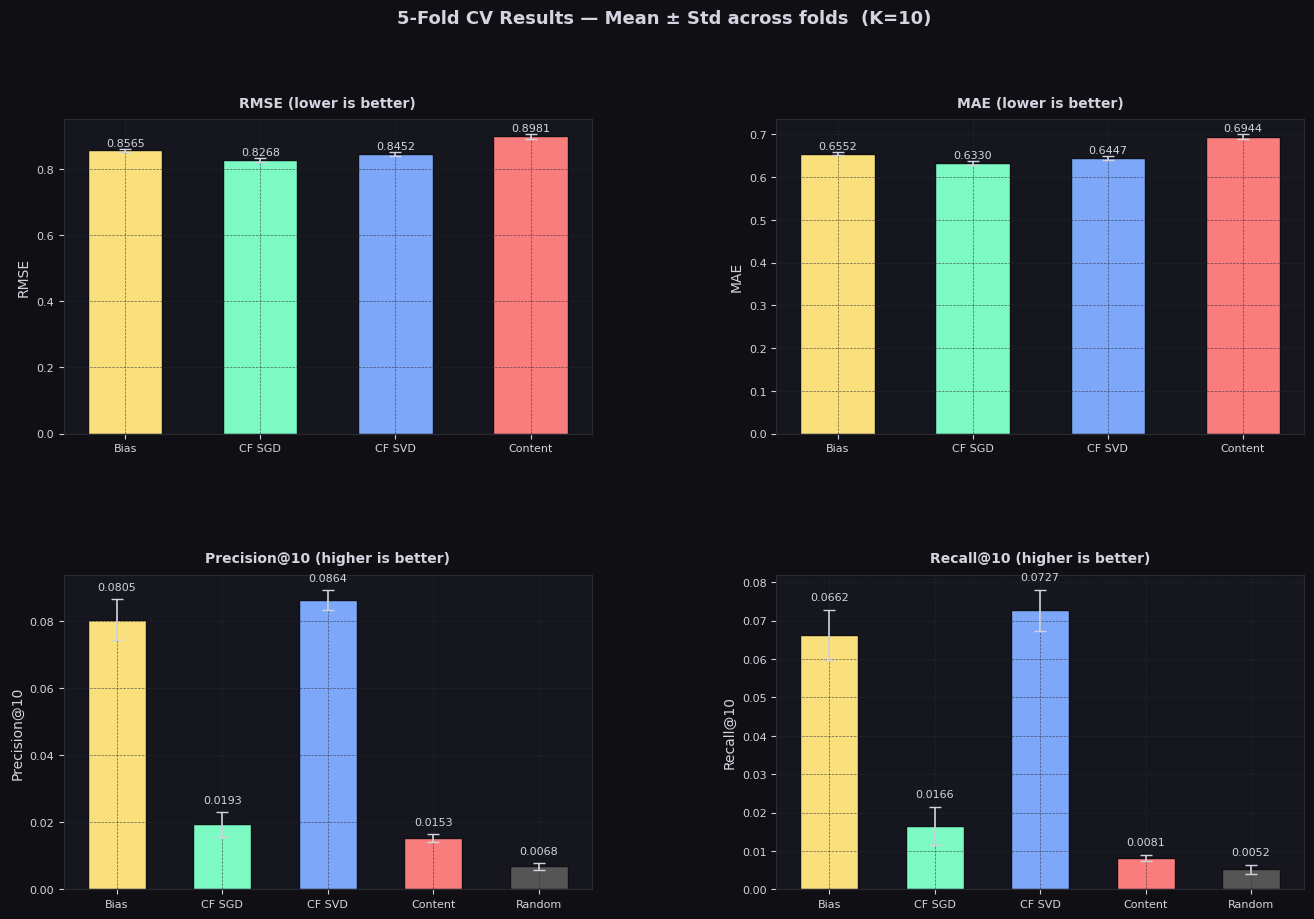

In [34]:
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

model_names_all     = list(cv_results.keys())
model_names_rmse    = [m for m in model_names_all if m != "Random"]
colors_rmse         = [ACCENT4, ACCENT, ACCENT3, ACCENT2]
colors_all          = [ACCENT4, ACCENT, ACCENT3, ACCENT2, "#555555"]
short_names_rmse    = ["Bias", "CF SGD", "CF SVD", "Content"]
short_names_all     = ["Bias", "CF SGD", "CF SVD", "Content", "Random"]

def metric_bar(ax, metric, ylabel, title, model_list, color_list, name_list):
    means = [np.mean(cv_results[m][metric]) for m in model_list]
    stds  = [np.std(cv_results[m][metric])  for m in model_list]
    x     = np.arange(len(model_list))
    bars  = ax.bar(x, means, color=color_list, edgecolor=BG, width=0.55,
                   yerr=stds, capsize=4,
                   error_kw={"ecolor": TEXT_C, "linewidth": 1.2})
    for bar, v, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2,
                v + s + 0.002,
                f"{v:.4f}", ha="center", va="bottom",
                color=TEXT_C, fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(name_list)
    ax.set_ylabel(ylabel)
    style_ax(ax, title)

metric_bar(fig.add_subplot(gs[0, 0]), "rmse",      "RMSE",         "RMSE (lower is better)",         model_names_rmse, colors_rmse, short_names_rmse)
metric_bar(fig.add_subplot(gs[0, 1]), "mae",       "MAE",          "MAE (lower is better)",          model_names_rmse, colors_rmse, short_names_rmse)
metric_bar(fig.add_subplot(gs[1, 0]), "precision", "Precision@10", "Precision@10 (higher is better)", model_names_all,  colors_all,  short_names_all)
metric_bar(fig.add_subplot(gs[1, 1]), "recall",    "Recall@10",    "Recall@10 (higher is better)",    model_names_all,  colors_all,  short_names_all)

fig.suptitle(f"5-Fold CV Results — Mean ± Std across folds  (K={K})",
             color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


## 8. Per-Fold Detail — RMSE

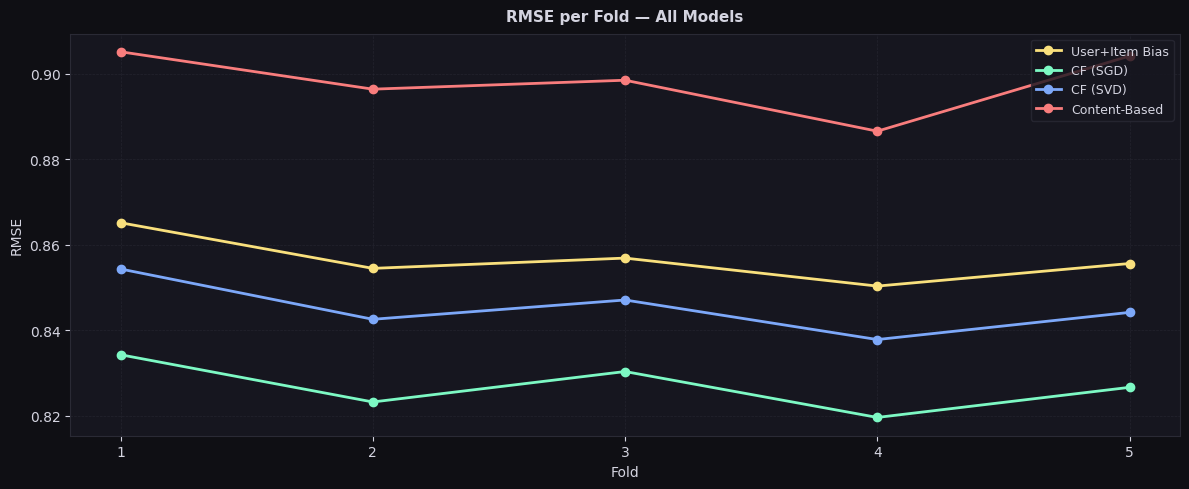


Per-fold RMSE:
  Model                 Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
  User+Item Bias        0.8651  0.8545  0.8569  0.8503  0.8556
  CF (SGD)              0.8342  0.8232  0.8303  0.8196  0.8266
  CF (SVD)              0.8543  0.8425  0.8471  0.8378  0.8442
  Content-Based         0.9051  0.8964  0.8985  0.8865  0.9041
  Random                1.8481  1.8469  1.8399  1.8432  1.8480


In [36]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL)

fold_x = np.arange(1, 6)
for model, color in zip(model_names, colors):
    if model=='Random':
        continue
    fold_rmses = cv_results[model]["rmse"]
    ax.plot(fold_x, fold_rmses, color=color, lw=2, marker="o",
            markersize=6, label=model)

ax.set_xlabel("Fold", color=TEXT_C)
ax.set_ylabel("RMSE", color=TEXT_C)
ax.set_xticks(fold_x)
ax.tick_params(colors=TEXT_C)
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=9)
for sp in ax.spines.values(): sp.set_edgecolor(GRID_C)
ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)
ax.set_title("RMSE per Fold — All Models", color=TEXT_C,
             fontweight="bold", fontsize=11, pad=9)

fig.tight_layout()
plt.show()

print("\nPer-fold RMSE:")
print(f"  {'Model':<20}", end="")
for f in range(1, 6): print(f"  Fold {f}", end="")
print()
for model in model_names:
    print(f"  {model:<20}", end="")
    for v in cv_results[model]["rmse"]:
        print(f"  {v:.4f}", end="")
    print()


## 9. Save Results

In [31]:
save_data = {}
for model_name, metrics in cv_results.items():
    save_data[model_name] = {
        metric: {
            "mean": float(np.mean(vals)),
            "std":  float(np.std(vals)),
            "folds": [float(v) for v in vals]
        }
        for metric, vals in metrics.items()
    }

with open("results_cv.json", "w") as f:
    json.dump(save_data, f, indent=2)

print("Saved: results_cv.json")
print()
print(json.dumps({
    k: {m: {"mean": round(v["mean"], 4), "std": round(v["std"], 4)}
        for m, v in metrics.items()}
    for k, metrics in save_data.items()
}, indent=2))


Saved: results_cv.json

{
  "User+Item Bias": {
    "rmse": {
      "mean": 0.8565,
      "std": 0.0049
    },
    "mae": {
      "mean": 0.6552,
      "std": 0.0041
    },
    "precision": {
      "mean": 0.0805,
      "std": 0.0061
    },
    "recall": {
      "mean": 0.0662,
      "std": 0.0065
    }
  },
  "CF (SGD)": {
    "rmse": {
      "mean": 0.8268,
      "std": 0.0052
    },
    "mae": {
      "mean": 0.633,
      "std": 0.0037
    },
    "precision": {
      "mean": 0.0193,
      "std": 0.0036
    },
    "recall": {
      "mean": 0.0166,
      "std": 0.0049
    }
  },
  "CF (SVD)": {
    "rmse": {
      "mean": 0.8452,
      "std": 0.0055
    },
    "mae": {
      "mean": 0.6447,
      "std": 0.0045
    },
    "precision": {
      "mean": 0.0864,
      "std": 0.003
    },
    "recall": {
      "mean": 0.0727,
      "std": 0.0053
    }
  },
  "Content-Based": {
    "rmse": {
      "mean": 0.8981,
      "std": 0.0067
    },
    "mae": {
      "mean": 0.6944,
      "std": 0.00